In [1]:
import pandas as pd
import scanpy as sc
import numpy as np

from hcrseq.scRNA.analysis import get_repair_df
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [2]:
adata = sc.read('../data/P3_clustered.v0.h5ad')

In [3]:
adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})

/tmp/ipykernel_168855/826239772.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})


In [4]:
adata = adata[adata.obs['transfected']]

In [5]:
adata_all = adata.copy()

In [6]:
x = pd.crosstab(adata_all.obs['label'],adata_all.obs['timepoint'])

cl_use = x.index[x['2h'] >= 25]

adata = adata_all[adata_all.obs['label'].isin(cl_use) & (adata_all.obs['timepoint']=='2h')]


In [7]:
ncell = [1,2,3,4,5,10,20,30,100,500]


nit = 100

dfs = list()
for n in ncell:
    for it in range(0,nit):
        obs_idx = adata.obs.groupby('label',observed=True).sample(n,replace=True).index

        df = get_repair_df(adata[obs_idx,:],groupby=['label'])
        df['N'] = n

        dfs.append(df)
df = pd.concat(dfs,axis=0).reset_index()

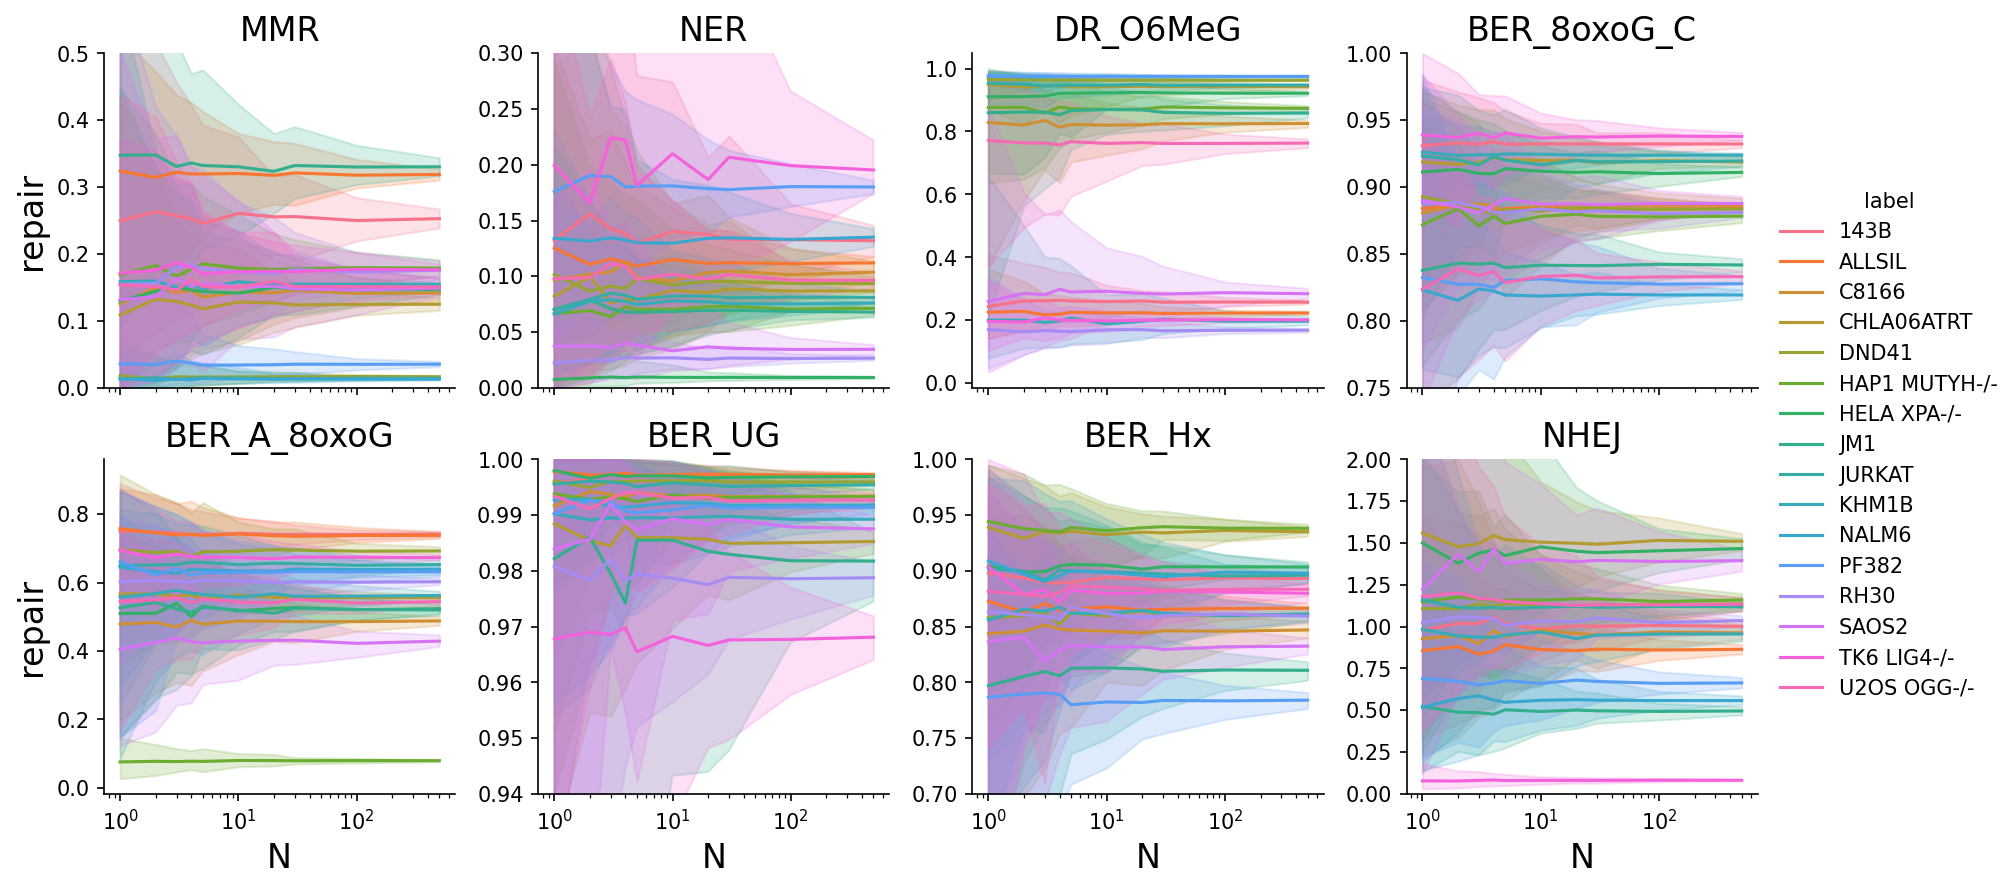

In [8]:
g = sns.relplot(data=df,x="N",y="repair",
            col="pathway",col_wrap=4,hue="label",kind="line",facet_kws={'sharey': False},
           errorbar = lambda x : np.quantile(x,[.025,.975]),height=3)

g.axes_dict['NER'].set_ylim(0,.3)
g.axes_dict['NHEJ'].set_ylim(0,2)
g.axes_dict['BER_Hx'].set_ylim(.7,1)
g.axes_dict['BER_UG'].set_ylim(.94,1)
g.axes_dict['MMR'].set_ylim(0,.5)
g.axes_dict['BER_8oxoG_C'].set_ylim(.75,1)

g.set(xscale='log')
g.set_titles(template="{col_name}",size=16) 

plt.savefig('pdf/figure7_scRNA_downsampling.pdf')